In [1]:
# Churn model is a predictive model that tells whether a user is likely to stop using the services or not

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import joblib

In [3]:
df = pd.read_csv('C:/files/programming/Python/2025/jupyter/projects/churn_prediction_model/data/netflix_customer_churn.csv')

# EDA

df = pd.read_csv('C:/files/programming/Python/2025/jupyter/projects/churn_prediction_model/data/netflix_customer_churn.csv')
df.sample(7)

In [4]:
print(df['customer_id'].nunique())
print(df.shape)
print("Info:")
print(df.info())

5000
(5000, 14)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int

In [5]:
print(df['churned'].value_counts(normalize=True)*100)

churned
1    50.3
0    49.7
Name: proportion, dtype: float64


<Axes: xlabel='subscription_type', ylabel='count'>

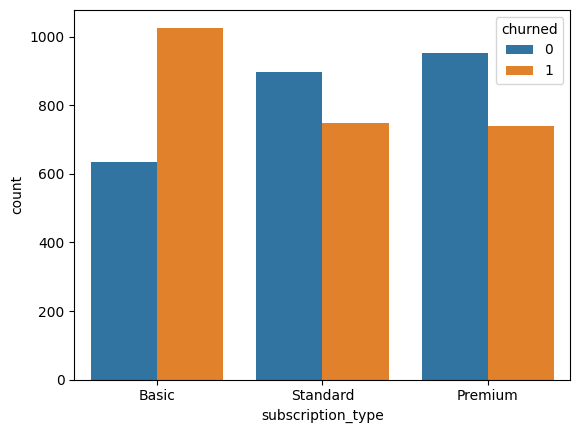

In [6]:
sns.countplot(x=df['subscription_type'],hue=df['churned'],data=df)

In [7]:
# basic plan users churn more

<Axes: xlabel='device', ylabel='count'>

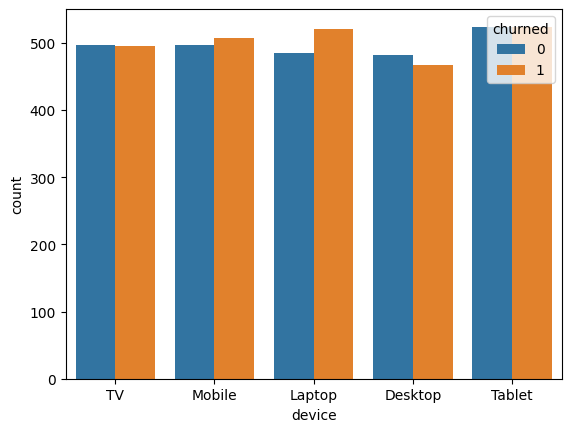

In [8]:
sns.countplot(x=df['device'],hue=df['churned'],data=df)

In [9]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

In [11]:
df['churned'].value_counts(normalize=True)

churned
1    0.503
0    0.497
Name: proportion, dtype: float64

<Axes: xlabel='churned', ylabel='watch_hours'>

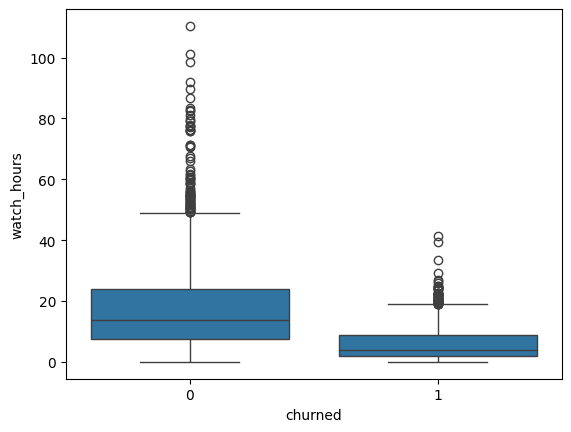

In [12]:
sns.boxplot(x='churned', y='watch_hours', data=df)

In [13]:
# churned users have less watch hours (3-5 median)

<Axes: xlabel='churned', ylabel='age'>

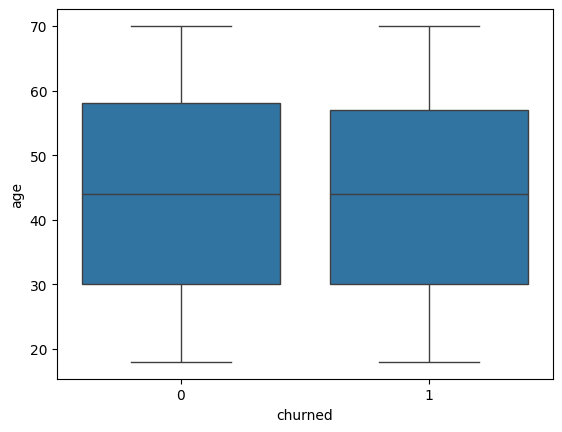

In [14]:
sns.boxplot(x='churned',y='age',data=df)

In [15]:
df.groupby('churned')['age'].mean()

churned
0    43.902213
1    43.793241
Name: age, dtype: float64

# Preprocessing

In [16]:
X= df.drop(['customer_id','churned'],axis=1)
y=df['churned']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
num_cols = [
    'age', 'watch_hours', 'last_login_days',
    'monthly_fee', 'number_of_profiles',
    'avg_watch_time_per_day'
]

In [19]:
cat_cols = [
    'gender', 'subscription_type', 'region',
    'device', 'payment_method', 'favorite_genre'
]

In [20]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',num_transformer,num_cols),
        ('cat_cols',cat_transformer,cat_cols)
    ],remainder = "passthrough"
)

# Training

In [22]:
pipeline = Pipeline(
    steps=[
        ('pre',preprocessor),
        ('model',XGBClassifier(
            random_state=42,
n_estimators=200,
        max_depth=5,
        learning_rate=0.05
        ))
        
    ]
)

In [23]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_cols', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [24]:
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       497
           1       1.00      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [25]:
'customer_id' in X_train.columns

False

<Axes: xlabel='churned', ylabel='last_login_days'>

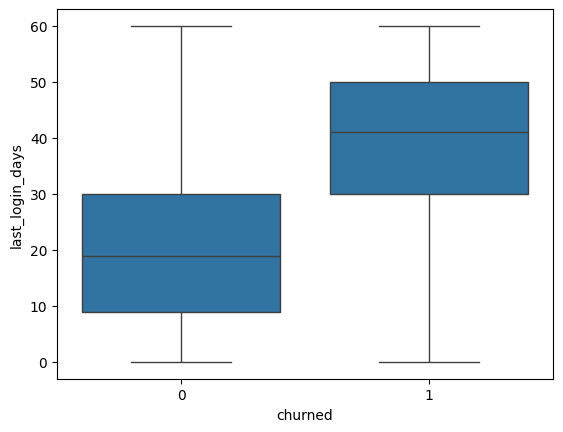

In [26]:
sns.boxplot(x='churned', y='last_login_days', data=df)

In [27]:
print(X_train.shape, X_test.shape)
print(X_train.columns)
print(y_train.value_counts())
print(y_test.value_counts())

(4000, 12) (1000, 12)
Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='object')
churned
1    2012
0    1988
Name: count, dtype: int64
churned
1    503
0    497
Name: count, dtype: int64


In [28]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [29]:
df.groupby("churned")["last_login_days"].describe()

,count,mean,std,min,25%,50%,75%,max
churned,,,,,,,,
0,2485.0,21.771026,16.155030,0.0,9.0,19.0,30.0,60.0
1,2515.0,38.309344,14.751904,0.0,30.0,41.0,50.0,60.0


In [30]:
df.groupby("churned")["watch_hours"].describe()

,count,mean,std,min,25%,50%,75%,max
churned,,,,,,,,
0,2485.0,17.449590,13.923952,0.01,7.38,13.86,24.02,110.40
1,2515.0,5.918497,5.418978,0.01,1.83,4.06,8.71,41.33


In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')
print(scores)
print("Mean:", scores.mean())

[0.99001996 0.99100899 0.99501496 0.99600798 0.99602386]
Mean: 0.993615149422842


In [60]:
# Probability of Churning
probs = pipeline.predict_proba(X_test)[:, 1]
prob_percent = probs * 100

## Feature Importance(After OHE)

In [61]:
feature_names = pipeline.named_steps['pre'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_imp.head(10)

num__avg_watch_time_per_day             0.472394
cat_cols__payment_method_Crypto         0.099997
num__monthly_fee                        0.064717
cat_cols__payment_method_Gift Card      0.063414
num__last_login_days                    0.063321
num__number_of_profiles                 0.060913
num__watch_hours                        0.055352
cat_cols__payment_method_PayPal         0.013158
cat_cols__payment_method_Debit Card     0.012282
cat_cols__payment_method_Credit Card    0.009316
dtype: float32

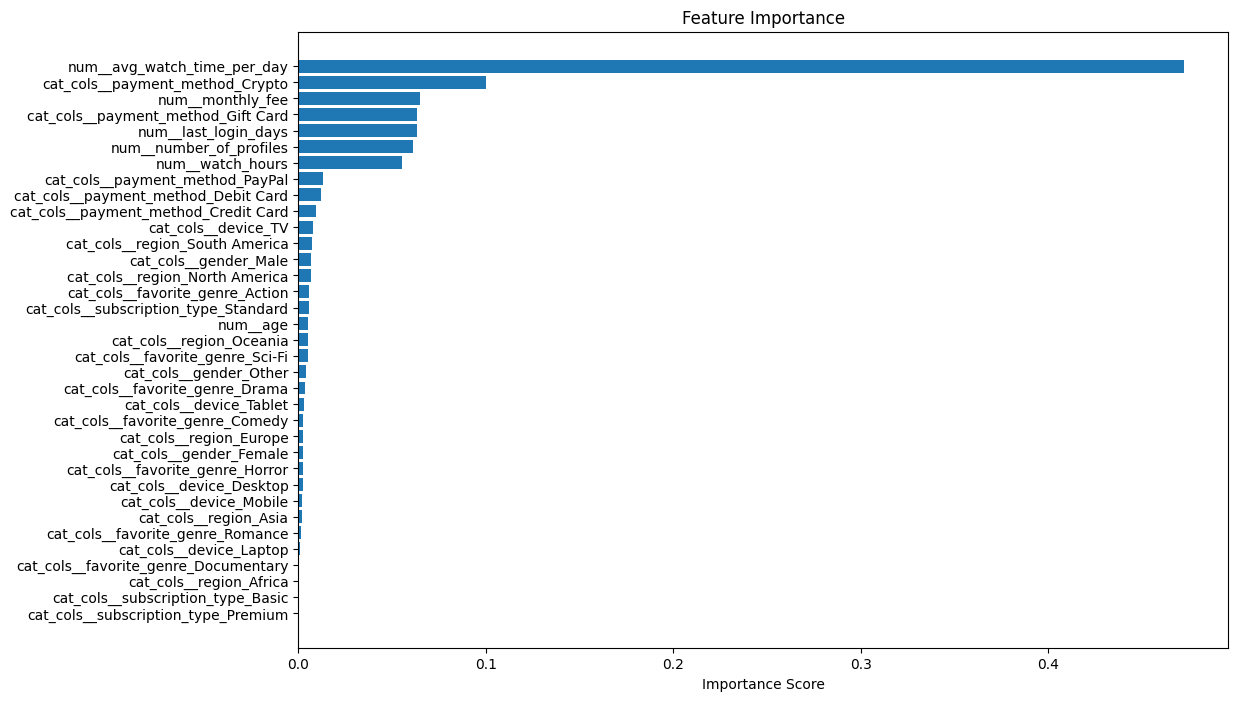

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Extract names after preprocessing
feature_names = pipeline.named_steps['pre'].get_feature_names_out()

# Extract importance from XGBoost
importances = pipeline.named_steps['model'].feature_importances_

# Sort descending
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance")

plt.barh(
    range(len(feature_names)),
    importances[indices]
)

plt.yticks(
    range(len(feature_names)),
    feature_names[indices]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.show()

In [77]:
joblib.dump(pipeline, "netflix_churn_pipeline.pkl")

['netflix_churn_pipeline.pkl']